# Transformer fMRI Forecasting Paper Notebook

Transformer-only forecasting pipeline with shared parsing/training utilities and empirical information-theoretic analysis.

In [1]:
import json
import sys
import time
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

REPO_ROOT = Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("Repo root:", REPO_ROOT)
print("Python:", sys.executable)

Repo root: /Users/oscarzhang/Desktop/Project Folder/fmri_forecasting
Python: /Users/oscarzhang/Desktop/Project Folder/fmri_forecasting/venv/bin/python


/Users/oscarzhang/Desktop/Project Folder/fmri_forecasting/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from utils.parse_data import (
    load_dataset,
    split_by_subject,
    normalize_items,
    build_sliding_windows,
)

from utils.training import (
    FMRIWindowDataset,
    DeltaAwareLoss,
    predict_forecasting_model,
    compute_rmse,
    compute_naive_rmse,
    compute_rmsse,
)

from models.transformer.transformer_api_library import transformer_model_generator

print("Shared utilities imported successfully.")

Shared utilities imported successfully.


In [3]:
CONFIG = SimpleNamespace(
    root_dir="data/pooled_stratified_share",
    M=50,
    H=3,
    stride=1,
    test_ratio=0.2,
    random_state=42,
    epochs=20,
    batch_size=512,
    checkpoint_every=10,
    results_dir="results_paper/transformer",
    checkpoint_dir="checkpoints_paper/transformer",
    figure_dir="results_paper/transformer/figures",

    d_model=64,
    nhead=4,
    num_layers=2,
    dropout=0.1,

    scatter_sample_size=20000,
    mi_sample_size=50000,
    ablation_sample_size=1500,
    random_seed=42,
    mi_bins=32,
)

Path(CONFIG.results_dir).mkdir(parents=True, exist_ok=True)
Path(CONFIG.checkpoint_dir).mkdir(parents=True, exist_ok=True)
Path(CONFIG.figure_dir).mkdir(parents=True, exist_ok=True)

CONFIG

namespace(root_dir='data/pooled_stratified_share',
          M=50,
          H=3,
          stride=1,
          test_ratio=0.2,
          random_state=42,
          epochs=20,
          batch_size=512,
          checkpoint_every=10,
          results_dir='results_paper/transformer',
          checkpoint_dir='checkpoints_paper/transformer',
          figure_dir='results_paper/transformer/figures',
          d_model=64,
          nhead=4,
          num_layers=2,
          dropout=0.1,
          scatter_sample_size=20000,
          mi_sample_size=50000,
          ablation_sample_size=1500,
          random_seed=42,
          mi_bins=32)

In [4]:
def safe_name(name):
    return str(name).lower().replace(" ", "_").replace("/", "_")


def get_device():
    if torch.backends.mps.is_available():
        device = torch.device("mps")
        print("Using Apple Silicon GPU (MPS)")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
        print(f"Using NVIDIA CUDA GPU: {torch.cuda.get_device_name(0)}")
    else:
        device = torch.device("cpu")
        print("Using CPU")
    return device


def dataloader_pin_memory(device):
    return device.type == "cuda"


def savefig(name, dpi=300):
    path = Path(CONFIG.figure_dir) / name
    plt.tight_layout()
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved figure: {path}")
    plt.show()


def flatten_time_roi(arr):
    arr = np.asarray(arr)
    if arr.ndim == 3:
        return arr.reshape(-1, arr.shape[-1])
    return arr


def compute_pve(y_true, y_pred, eps=1e-12):
    return float(1.0 - np.var(y_true - y_pred) / (np.var(y_true) + eps))


def compute_overall_corr(y_true, y_pred):
    yt = np.asarray(y_true).ravel()
    yp = np.asarray(y_pred).ravel()
    if yt.std() < 1e-12 or yp.std() < 1e-12:
        return np.nan
    return float(np.corrcoef(yt, yp)[0, 1])


def empirical_entropy_1d(x, bins=32, eps=1e-12):
    x = np.asarray(x).ravel()
    counts, _ = np.histogram(x, bins=bins)
    p = counts.astype(np.float64)
    p = p / max(p.sum(), eps)
    p = p[p > 0]
    return float(-np.sum(p * np.log(p + eps)))


def empirical_mi_1d(x, y, bins=32, eps=1e-12):
    x = np.asarray(x).ravel()
    y = np.asarray(y).ravel()

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) == 0 or np.std(x) < eps or np.std(y) < eps:
        return 0.0

    joint_counts, _, _ = np.histogram2d(x, y, bins=bins)
    pxy = joint_counts.astype(np.float64)
    total = pxy.sum()

    if total <= 0:
        return 0.0

    pxy = pxy / total
    px = pxy.sum(axis=1, keepdims=True)
    py = pxy.sum(axis=0, keepdims=True)

    mask = pxy > 0
    mi = np.sum(pxy[mask] * np.log((pxy[mask] + eps) / ((px @ py)[mask] + eps)))
    return float(max(mi, 0.0))


def compute_per_roi_metrics(y_true, y_pred, bins=32, eps=1e-12):
    yt = flatten_time_roi(y_true)
    yp = flatten_time_roi(y_pred)

    rows = []
    for r in range(yt.shape[1]):
        true_r = yt[:, r]
        pred_r = yp[:, r]
        err = true_r - pred_r

        mse = float(np.mean(err ** 2))
        rmse = float(np.sqrt(mse))
        pve = float(1.0 - np.var(err) / (np.var(true_r) + eps))

        if true_r.std() < eps or pred_r.std() < eps:
            corr = np.nan
        else:
            corr = float(np.corrcoef(true_r, pred_r)[0, 1])

        entropy = empirical_entropy_1d(true_r, bins=bins, eps=eps)
        mi = empirical_mi_1d(true_r, pred_r, bins=bins, eps=eps)
        normalized_mi = float(mi / (entropy + eps)) if entropy > eps else np.nan

        rows.append({
            "roi": r,
            "mse": mse,
            "rmse": rmse,
            "corr": corr,
            "pve": pve,
            "empirical_mi": mi,
            "empirical_entropy": entropy,
            "normalized_empirical_mi": normalized_mi,
            "true_std": float(np.std(true_r)),
            "pred_std": float(np.std(pred_r)),
        })

    return pd.DataFrame(rows)


def empirical_cross_roi_mi_matrix(arr, bins=32, sample_size=None, seed=42):
    arr2 = flatten_time_roi(arr)

    if sample_size is not None and len(arr2) > sample_size:
        rng = np.random.default_rng(seed)
        idx = rng.choice(len(arr2), size=sample_size, replace=False)
        arr2 = arr2[idx]

    n_roi = arr2.shape[1]
    mat = np.zeros((n_roi, n_roi), dtype=np.float64)

    for i in range(n_roi):
        for j in range(n_roi):
            if i == j:
                mat[i, j] = 0.0
            else:
                mat[i, j] = empirical_mi_1d(arr2[:, i], arr2[:, j], bins=bins)

    return mat

In [5]:
def load_and_prepare_data(cfg):
    root_dir = Path(cfg.root_dir)
    if not root_dir.exists():
        raise FileNotFoundError(f"Dataset folder not found: {root_dir}")

    print("=" * 80)
    print("Loading raw dataset")
    print("=" * 80)

    start = time.time()
    dataset = load_dataset(root_dir)
    load_seconds = time.time() - start
    print(f"Loaded {len(dataset)} runs in {load_seconds:.2f} seconds")

    print("\nSplitting dataset by subject")
    train_items, test_items = split_by_subject(
        dataset,
        test_ratio=cfg.test_ratio,
        test_subjects=None,
        random_state=cfg.random_state,
        verbose=True,
    )

    print("\nNormalizing train and test groups separately")
    train_items = normalize_items(train_items)
    test_items = normalize_items(test_items)

    print("\nBuilding sliding windows")
    X_train, Y_train = build_sliding_windows(train_items, M=cfg.M, H=cfg.H, stride=cfg.stride)
    X_test, Y_test = build_sliding_windows(test_items, M=cfg.M, H=cfg.H, stride=cfg.stride)

    print("\nFinal data shapes:")
    print(f"X_train: {X_train.shape}")
    print(f"Y_train: {Y_train.shape}")
    print(f"X_test : {X_test.shape}")
    print(f"Y_test : {Y_test.shape}")

    if len(X_train) == 0 or len(X_test) == 0:
        raise ValueError("No valid forecasting windows were created.")

    metadata = {
        "root_dir": str(root_dir),
        "num_raw_runs": int(len(dataset)),
        "train_runs": int(len(train_items)),
        "test_runs": int(len(test_items)),
        "train_subjects": sorted(list({item["subject"] for item in train_items})),
        "test_subjects": sorted(list({item["subject"] for item in test_items})),
        "X_train_shape": list(X_train.shape),
        "Y_train_shape": list(Y_train.shape),
        "X_test_shape": list(X_test.shape),
        "Y_test_shape": list(Y_test.shape),
        "load_seconds": float(load_seconds),
        "M": int(cfg.M),
        "H": int(cfg.H),
        "stride": int(cfg.stride),
    }

    with open(Path(cfg.results_dir) / "dataset_metadata.json", "w") as f:
        json.dump(metadata, f, indent=2)

    return X_train, Y_train, X_test, Y_test, metadata


X_train, Y_train, X_test, Y_test, metadata = load_and_prepare_data(CONFIG)

Loading raw dataset
Scanning and loading dataset (optimized fixed schema mode)...
Loaded: 2144 runs from 6 subjects
Subjects: ['subjOenz4SHyaO', 'subjQX6R7rImeb', 'subjoVC0sHUB_P', 'subjqFdsBbuiHF', 'subjtySNgRhV65', 'subjxpYwO4azeZ']
Loaded 2144 runs in 0.61 seconds

Splitting dataset by subject
Train subjects: ['subjqFdsBbuiHF', 'subjoVC0sHUB_P', 'subjxpYwO4azeZ', 'subjtySNgRhV65']
Test subjects : ['subjQX6R7rImeb', 'subjOenz4SHyaO']
Train runs: 1440
Test runs : 704

Normalizing train and test groups separately

Building sliding windows

Final data shapes:
X_train: (250560, 50, 19)
Y_train: (250560, 3, 19)
X_test : (122496, 50, 19)
Y_test : (122496, 3, 19)


In [6]:
def make_train_val_split(X_train, Y_train, val_ratio=0.1):
    split_idx = int(len(X_train) * (1 - val_ratio))

    X_tr = X_train[:split_idx]
    Y_tr = Y_train[:split_idx]
    X_val = X_train[split_idx:]
    Y_val = Y_train[split_idx:]

    print("\nTrain/validation split:")
    print(f"Train subset: {X_tr.shape}, {Y_tr.shape}")
    print(f"Val subset  : {X_val.shape}, {Y_val.shape}")

    return X_tr, Y_tr, X_val, Y_val


X_tr, Y_tr, X_val, Y_val = make_train_val_split(X_train, Y_train, val_ratio=0.1)

n_roi = X_train.shape[2]
device = get_device()


Train/validation split:
Train subset: (225504, 50, 19), (225504, 3, 19)
Val subset  : (25056, 50, 19), (25056, 3, 19)
Using Apple Silicon GPU (MPS)


In [7]:
model = transformer_model_generator(
    n_roi=n_roi,
    M=CONFIG.M,
    H=CONFIG.H,
    d_model=CONFIG.d_model,
    nhead=CONFIG.nhead,
    num_layers=CONFIG.num_layers,
    dropout=CONFIG.dropout,
).to(device)

print(model)

num_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {num_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

model_config = {
    "model": "Transformer",
    "n_roi": int(n_roi),
    "M": int(CONFIG.M),
    "H": int(CONFIG.H),
    "d_model": int(CONFIG.d_model),
    "nhead": int(CONFIG.nhead),
    "num_layers": int(CONFIG.num_layers),
    "dropout": float(CONFIG.dropout),
    "total_parameters": int(num_params),
    "trainable_parameters": int(trainable_params),
}

with open(Path(CONFIG.results_dir) / "model_config.json", "w") as f:
    json.dump(model_config, f, indent=2)

TransformerForecastModel(
  (input_proj): Linear(in_features=19, out_features=64, bias=True)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (output_layer): Linear(in_features=64, out_features=57, bias=True)
)
Total parameters: 570,489
Trainable parameters: 570,489


In [8]:
def save_model_checkpoint(model, optimizer, epoch, train_loss, val_loss, cfg, n_roi):
    ckpt_path = Path(cfg.checkpoint_dir) / f"transformer_epoch_{epoch:03d}.pt"

    checkpoint = {
        "model_name": "Transformer",
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "train_loss": float(train_loss),
        "val_loss": float(val_loss),
        "M": cfg.M,
        "H": cfg.H,
        "stride": cfg.stride,
        "n_roi": n_roi,
        "d_model": cfg.d_model,
        "nhead": cfg.nhead,
        "num_layers": cfg.num_layers,
        "dropout": cfg.dropout,
    }

    torch.save(checkpoint, ckpt_path)
    print(f"Checkpoint saved: {ckpt_path}")


def train_transformer_with_checkpoints(model, X_tr, Y_tr, X_val, Y_val, cfg, device, n_roi):
    pin_memory = dataloader_pin_memory(device)

    train_loader = DataLoader(
        FMRIWindowDataset(X_tr, Y_tr),
        batch_size=cfg.batch_size,
        shuffle=True,
        pin_memory=pin_memory,
    )

    val_loader = DataLoader(
        FMRIWindowDataset(X_val, Y_val),
        batch_size=cfg.batch_size,
        shuffle=False,
        pin_memory=pin_memory,
    )

    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=2,
    )

    criterion = DeltaAwareLoss(alpha=0.3, delta=0.5)

    best_val_loss = float("inf")
    best_state = None
    history = []
    start_time = time.time()

    print(f"\nTraining Transformer for {cfg.epochs} epochs")

    epoch_bar = tqdm(range(1, cfg.epochs + 1), desc="Epochs")

    for epoch in epoch_bar:
        model.train()
        total_train_loss = 0.0

        train_bar = tqdm(train_loader, desc=f"Train {epoch:03d}", leave=False)
        for X_batch, Y_batch in train_bar:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)

            optimizer.zero_grad()
            loss = criterion(model(X_batch), Y_batch)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()
            train_bar.set_postfix(loss=f"{loss.item():.4f}")

        avg_train_loss = total_train_loss / max(len(train_loader), 1)

        model.eval()
        total_val_loss = 0.0

        val_bar = tqdm(val_loader, desc=f"Val {epoch:03d}", leave=False)
        with torch.no_grad():
            for X_batch, Y_batch in val_bar:
                X_batch = X_batch.to(device)
                Y_batch = Y_batch.to(device)

                loss = criterion(model(X_batch), Y_batch)
                total_val_loss += loss.item()
                val_bar.set_postfix(loss=f"{loss.item():.4f}")

        avg_val_loss = total_val_loss / max(len(val_loader), 1)
        scheduler.step(avg_val_loss)

        current_lr = optimizer.param_groups[0]["lr"]

        history.append({
            "epoch": epoch,
            "train_loss": float(avg_train_loss),
            "val_loss": float(avg_val_loss),
            "lr": float(current_lr),
        })

        epoch_bar.set_postfix(
            train=f"{avg_train_loss:.6f}",
            val=f"{avg_val_loss:.6f}",
            lr=f"{current_lr:.2e}",
        )

        print(
            f"Epoch {epoch:03d}/{cfg.epochs} | "
            f"train: {avg_train_loss:.6f} | "
            f"val: {avg_val_loss:.6f} | "
            f"lr: {current_lr:.2e}"
        )

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if epoch % cfg.checkpoint_every == 0:
            save_model_checkpoint(
                model=model,
                optimizer=optimizer,
                epoch=epoch,
                train_loss=avg_train_loss,
                val_loss=avg_val_loss,
                cfg=cfg,
                n_roi=n_roi,
            )

    train_time_minutes = (time.time() - start_time) / 60

    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"Best validation weights restored. Best val loss: {best_val_loss:.6f}")

    final_path = Path(cfg.checkpoint_dir) / "transformer_final.pt"
    torch.save(
        {
            "model_name": "Transformer",
            "model_state_dict": model.state_dict(),
            "M": cfg.M,
            "H": cfg.H,
            "stride": cfg.stride,
            "n_roi": n_roi,
            "d_model": cfg.d_model,
            "nhead": cfg.nhead,
            "num_layers": cfg.num_layers,
            "dropout": cfg.dropout,
            "best_val_loss": float(best_val_loss),
            "train_time_minutes": float(train_time_minutes),
        },
        final_path,
    )

    history_df = pd.DataFrame(history)
    history_df.to_csv(Path(cfg.results_dir) / "training_history.csv", index=False)

    print(f"Final PyTorch model saved: {final_path}")
    print(f"Finished training Transformer in {train_time_minutes:.2f} minutes")

    return model, history_df, train_time_minutes


model, history_df, train_time_minutes = train_transformer_with_checkpoints(
    model=model,
    X_tr=X_tr,
    Y_tr=Y_tr,
    X_val=X_val,
    Y_val=Y_val,
    cfg=CONFIG,
    device=device,
    n_roi=n_roi,
)


Training Transformer for 20 epochs


Epochs:   5%|▌         | 1/20 [00:27<08:50, 27.92s/it, lr=5.00e-04, train=0.297906, val=0.252173]

Epoch 001/20 | train: 0.297906 | val: 0.252173 | lr: 5.00e-04


Epochs:  10%|█         | 2/20 [00:56<08:26, 28.14s/it, lr=5.00e-04, train=0.281488, val=0.248609]

Epoch 002/20 | train: 0.281488 | val: 0.248609 | lr: 5.00e-04


...

Epoch 018/20 | train: 0.267368 | val: 0.243659 | lr: 5.00e-04


Epochs:  95%|█████████▌| 19/20 [08:51<00:27, 27.70s/it, lr=5.00e-04, train=0.266962, val=0.243465]

Epoch 019/20 | train: 0.266962 | val: 0.243465 | lr: 5.00e-04


Epochs: 100%|██████████| 20/20 [09:18<00:00, 27.90s/it, lr=5.00e-04, train=0.266517, val=0.243424]


Epoch 020/20 | train: 0.266517 | val: 0.243424 | lr: 5.00e-04
Checkpoint saved: checkpoints_paper/transformer/transformer_epoch_020.pt
Best validation weights restored. Best val loss: 0.243424
Final PyTorch model saved: checkpoints_paper/transformer/transformer_final.pt
Finished training Transformer in 9.30 minutes


Saved figure: results_paper/transformer/figures/training_curve.png


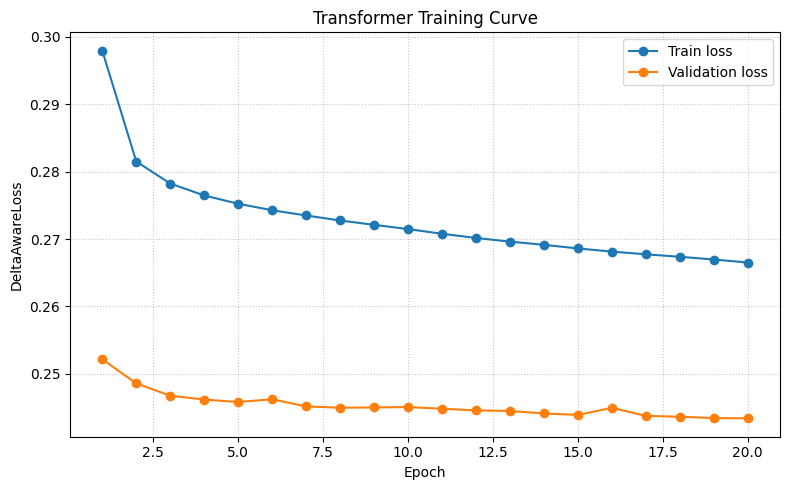

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("DeltaAwareLoss")
plt.title("Transformer Training Curve")
plt.grid(True, linestyle=":", alpha=0.7)
plt.legend()
savefig("training_curve.png")

In [10]:
print("Evaluating Transformer on test set")

preds, targets = predict_forecasting_model(
    model=model,
    X=X_test,
    Y=Y_test,
    batch_size=CONFIG.batch_size,
    device=device,
)

print("preds shape  :", preds.shape)
print("targets shape:", targets.shape)

np.save(Path(CONFIG.results_dir) / "Y_pred_transformer.npy", preds)
np.save(Path(CONFIG.results_dir) / "Y_true_transformer.npy", targets)

Evaluating Transformer on test set


/Users/oscarzhang/Desktop/Project Folder/fmri_forecasting/venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


preds shape  : (122496, 3, 19)
targets shape: (122496, 3, 19)


In [11]:
model_rmse = compute_rmse(targets, preds)
naive_rmse = compute_naive_rmse(X_test, Y_test)
model_rmsse = compute_rmsse(targets, preds, X_train)
pve = compute_pve(targets, preds)
overall_corr = compute_overall_corr(targets, preds)

horizon_scores = []
for h in range(targets.shape[1]):
    horizon_scores.append(compute_rmse(targets[:, h, :], preds[:, h, :]))

summary = {
    "model": "Transformer",
    "M": CONFIG.M,
    "H": CONFIG.H,
    "stride": CONFIG.stride,
    "epochs": CONFIG.epochs,
    "n_roi": n_roi,
    "model_rmse": model_rmse,
    "naive_rmse": naive_rmse,
    "rmsse": model_rmsse,
    "pve": pve,
    "overall_corr": overall_corr,
    "beat_naive": model_rmse < naive_rmse,
    "horizon_rmse": json.dumps([float(x) for x in horizon_scores]),
    "train_time_minutes": train_time_minutes,
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv(Path(CONFIG.results_dir) / "summary_for_report.csv", index=False)

with open(Path(CONFIG.results_dir) / "summary_for_report.json", "w") as f:
    json.dump(summary, f, indent=2)

display(summary_df)

horizon_df = pd.DataFrame({
    "horizon_step": np.arange(1, len(horizon_scores) + 1),
    "rmse": horizon_scores,
})
horizon_df.to_csv(Path(CONFIG.results_dir) / "horizon_rmse.csv", index=False)
display(horizon_df)

,model,M,H,stride,epochs,n_roi,model_rmse,naive_rmse,rmsse,pve,overall_corr,beat_naive,horizon_rmse,train_time_minutes
0,Transformer,50,3,1,20,19,0.802097,0.991941,1.011876,0.2646,0.515769,True,"[0.7036499977111816, 0.8296550512313843, 0.864...",9.301348


,horizon_step,rmse
0,1,0.703650
1,2,0.829655
2,3,0.864077


Saved figure: results_paper/transformer/figures/horizon_rmse.png


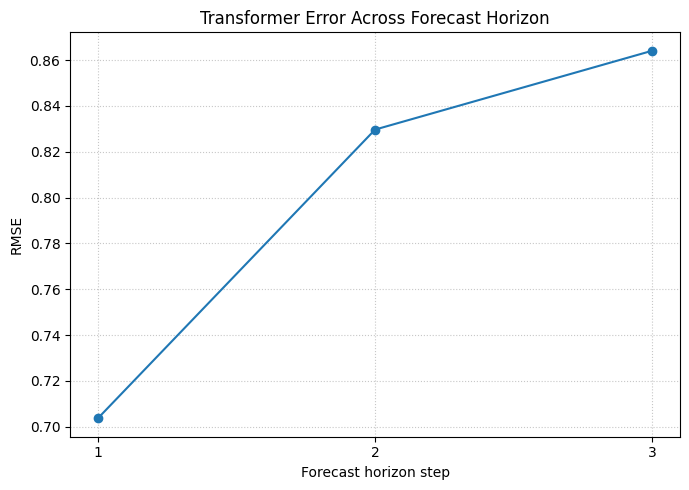

In [12]:
plt.figure(figsize=(7, 5))
plt.plot(horizon_df["horizon_step"], horizon_df["rmse"], marker="o")
plt.xlabel("Forecast horizon step")
plt.ylabel("RMSE")
plt.title("Transformer Error Across Forecast Horizon")
plt.xticks(horizon_df["horizon_step"])
plt.grid(True, linestyle=":", alpha=0.7)
savefig("horizon_rmse.png")

In [13]:
per_roi_df = compute_per_roi_metrics(
    targets,
    preds,
    bins=CONFIG.mi_bins,
)

per_roi_df.to_csv(Path(CONFIG.results_dir) / "per_roi_metrics.csv", index=False)

display(per_roi_df)

print("Highest PVE ROIs")
display(per_roi_df.sort_values("pve", ascending=False).head(5))

print("Lowest PVE ROIs")
display(per_roi_df.sort_values("pve", ascending=True).head(5))

,roi,mse,rmse,corr,pve,empirical_mi,empirical_entropy,normalized_empirical_mi,true_std,pred_std
0,0,0.681305,0.825412,0.476990,0.226893,0.137246,2.360778,0.058136,0.936504,0.470147
1,1,0.488803,0.699145,0.642247,0.409532,0.288679,2.033455,0.141965,0.908888,0.534375
2,2,0.603200,0.776660,0.560231,0.313814,0.199032,2.049665,0.097105,0.936073,0.518138
3,3,0.519214,0.720565,0.634846,0.396746,0.264737,2.037298,0.129945,0.918759,0.656095
4,4,0.752931,0.867716,0.415131,0.165210,0.098676,2.266439,0.043538,0.949534,0.474323
5,5,0.635116,0.796942,0.534118,0.285277,0.171027,2.114452,0.080885,0.942559,0.505515
6,6,0.791083,0.889429,0.385421,0.137664,0.085120,2.011220,0.042323,0.957018,0.468704
7,7,0.612485,0.782614,0.507610,0.256836,0.161538,2.028646,0.079629,0.904214,0.432914
8,8,0.864802,0.929948,0.310618,0.084361,0.051612,2.328945,0.022161,0.970864,0.408461
9,9,0.719716,0.848361,0.463288,0.214023,0.125788,2.358794,0.053327,0.956697,0.419540


Highest PVE ROIs


,roi,mse,rmse,corr,pve,empirical_mi,empirical_entropy,normalized_empirical_mi,true_std,pred_std
11,11,0.466011,0.682650,0.699487,0.484113,0.333714,2.080144,0.160429,0.950151,0.596305
13,13,0.548856,0.740848,0.641140,0.410934,0.279170,2.670814,0.104526,0.956156,0.602270
1,1,0.488803,0.699145,0.642247,0.409532,0.288679,2.033455,0.141965,0.908888,0.534375
3,3,0.519214,0.720565,0.634846,0.396746,0.264737,2.037298,0.129945,0.918759,0.656095
2,2,0.603200,0.776660,0.560231,0.313814,0.199032,2.049665,0.097105,0.936073,0.518138


Lowest PVE ROIs


,roi,mse,rmse,corr,pve,empirical_mi,empirical_entropy,normalized_empirical_mi,true_std,pred_std
8,8,0.864802,0.929948,0.310618,0.084361,0.051612,2.328945,0.022161,0.970864,0.408461
18,18,0.794086,0.891115,0.361085,0.118868,0.069510,2.049728,0.033912,0.949232,0.444607
6,6,0.791083,0.889429,0.385421,0.137664,0.085120,2.011220,0.042323,0.957018,0.468704
4,4,0.752931,0.867716,0.415131,0.165210,0.098676,2.266439,0.043538,0.949534,0.474323
16,16,0.420487,0.648450,0.442058,0.190848,0.250334,1.967550,0.127231,0.720056,0.366969


Saved figure: results_paper/transformer/figures/per_roi_rmse_ranked.png


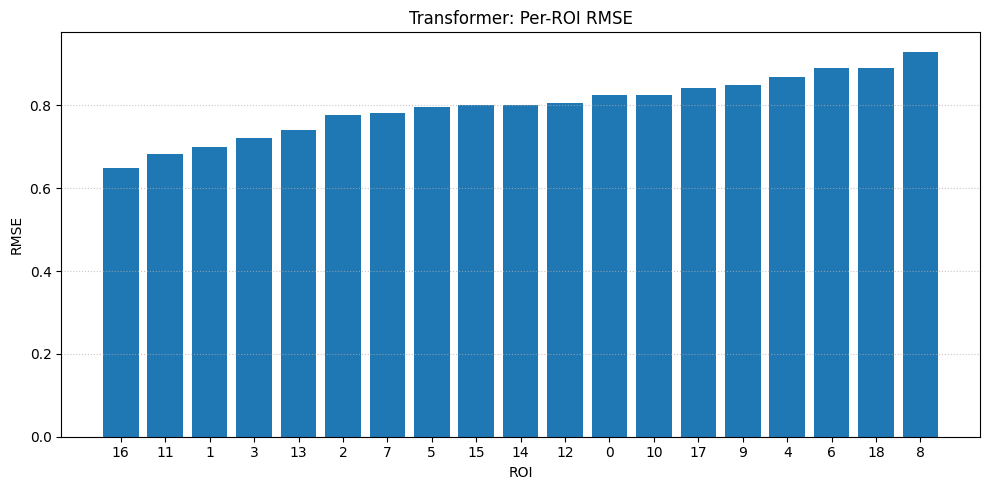

Saved figure: results_paper/transformer/figures/per_roi_correlation.png


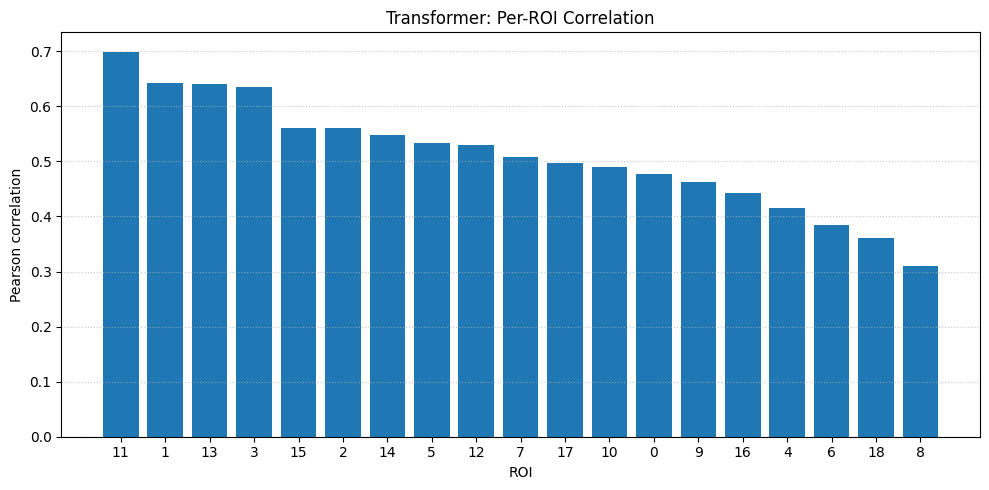

Saved figure: results_paper/transformer/figures/per_roi_pve.png


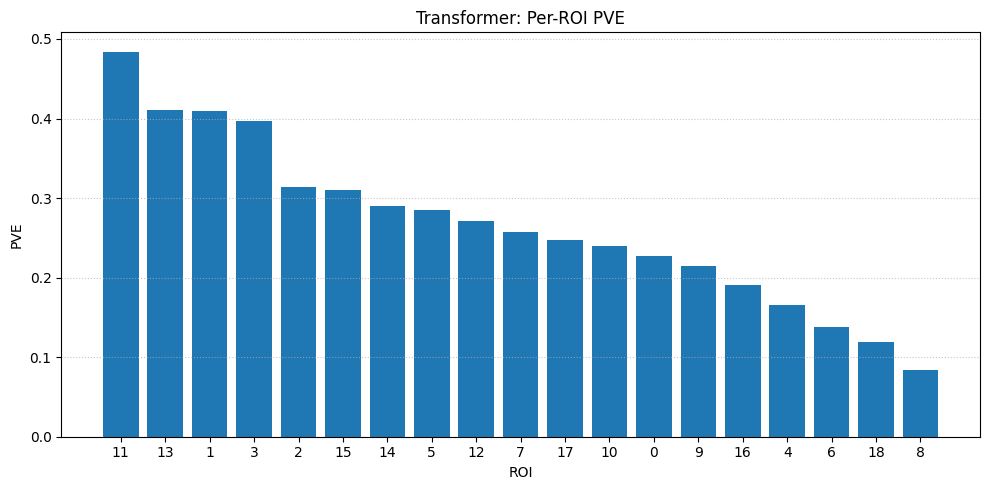

Saved figure: results_paper/transformer/figures/per_roi_empirical_mi.png


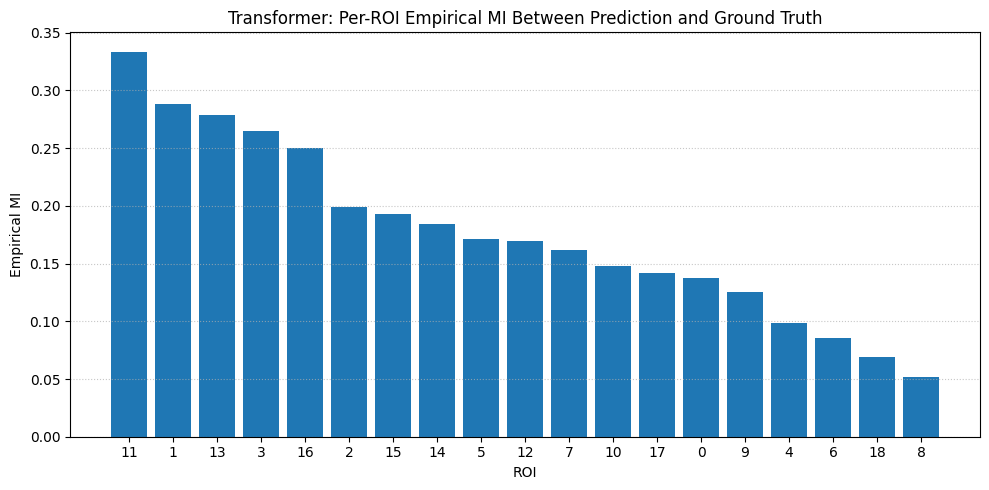

In [14]:
def plot_per_roi_bar(df, metric, title, ylabel, filename, ascending=False):
    plot_df = df.sort_values(metric, ascending=ascending)

    plt.figure(figsize=(10, 5))
    plt.bar(plot_df["roi"].astype(str), plot_df[metric])
    plt.xlabel("ROI")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(axis="y", linestyle=":", alpha=0.7)
    savefig(filename)


plot_per_roi_bar(
    per_roi_df,
    metric="rmse",
    title="Transformer: Per-ROI RMSE",
    ylabel="RMSE",
    filename="per_roi_rmse_ranked.png",
    ascending=True,
)

plot_per_roi_bar(
    per_roi_df,
    metric="corr",
    title="Transformer: Per-ROI Correlation",
    ylabel="Pearson correlation",
    filename="per_roi_correlation.png",
    ascending=False,
)

plot_per_roi_bar(
    per_roi_df,
    metric="pve",
    title="Transformer: Per-ROI PVE",
    ylabel="PVE",
    filename="per_roi_pve.png",
    ascending=False,
)

plot_per_roi_bar(
    per_roi_df,
    metric="empirical_mi",
    title="Transformer: Per-ROI Empirical MI Between Prediction and Ground Truth",
    ylabel="Empirical MI",
    filename="per_roi_empirical_mi.png",
    ascending=False,
)

In [ ]:
def select_roi_summary(per_roi_df, X_test, Y_test, preds):
    rows = []

    for r in sorted(per_roi_df["roi"].unique()):
        r = int(r)

        rows.append({
            "roi": r,
            "past_std": float(X_test[:, :, r].std()),
            "future_std": float(Y_test[:, :, r].std()),
            "prediction_std": float(preds[:, :, r].std()),
        })
        

    variability_df = pd.DataFrame(rows)

    metric_df = per_roi_df.copy()

    # Remove old variability columns if they already exist
    for col in ["past_std", "future_std", "pred_std", "prediction_std"]:
        if col in metric_df.columns:
            metric_df = metric_df.drop(columns=[col])

    merged = metric_df.merge(
        variability_df,
        on="roi",
        how="left",
    )

    valid = merged[
        np.isfinite(merged["pve"])
        & np.isfinite(merged["corr"])
        & (merged["future_std"] > 0.05)
    ].copy()

    if len(valid) < 3:
        valid = merged[
            np.isfinite(merged["pve"])
            & np.isfinite(merged["corr"])
        ].copy()

    ranked = valid.sort_values(
        "pve",
        ascending=False,
    ).reset_index(drop=True)

    best_roi = int(ranked.iloc[0]["roi"])
    median_roi = int(ranked.iloc[len(ranked) // 2]["roi"])
    worst_roi = int(ranked.iloc[-1]["roi"])

    return best_roi, median_roi, worst_roi, ranked


best_roi, median_roi, worst_roi, roi_ranked = select_roi_summary(
    per_roi_df=per_roi_df,
    X_test=X_test,
    Y_test=Y_test,
    preds=preds,
)

print(f"Best ROI by PVE: {best_roi}")
print(f"Median ROI by PVE: {median_roi}")
print(f"Worst ROI by PVE: {worst_roi}")

display_cols = [
    "roi",
    "rmse",
    "pve",
    "corr",
    "future_std",
    "prediction_std",
]

display(roi_ranked[display_cols])

Best ROI by PVE: 11
Median ROI by PVE: 7
Worst ROI by PVE: 8


,roi,rmse,pve,corr,future_std,prediction_std
0,11,0.682650,0.484113,0.699487,0.950151,0.596305
1,13,0.740848,0.410934,0.641140,0.956156,0.602270
2,1,0.699145,0.409532,0.642247,0.908888,0.534375
3,3,0.720565,0.396746,0.634846,0.918759,0.656095
4,2,0.776660,0.313814,0.560231,0.936073,0.518138
5,15,0.801128,0.310541,0.560995,0.959964,0.600565
6,14,0.801488,0.289486,0.548440,0.949435,0.621635
7,5,0.796942,0.285277,0.534118,0.942559,0.505515
8,12,0.806958,0.271118,0.530434,0.945142,0.596990
9,7,0.782614,0.256836,0.507610,0.904214,0.432914


Selected sample index: 122451
Best ROI: 11
Median ROI: 7
Worst ROI: 8
Saved figure: results_paper/transformer/figures/forecast_example_best_roi.png


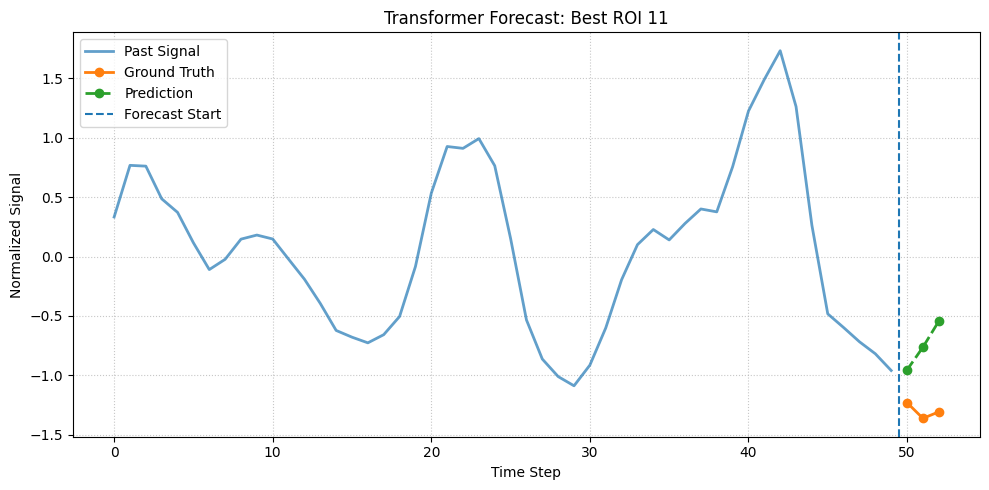

Saved figure: results_paper/transformer/figures/forecast_example_median_roi.png


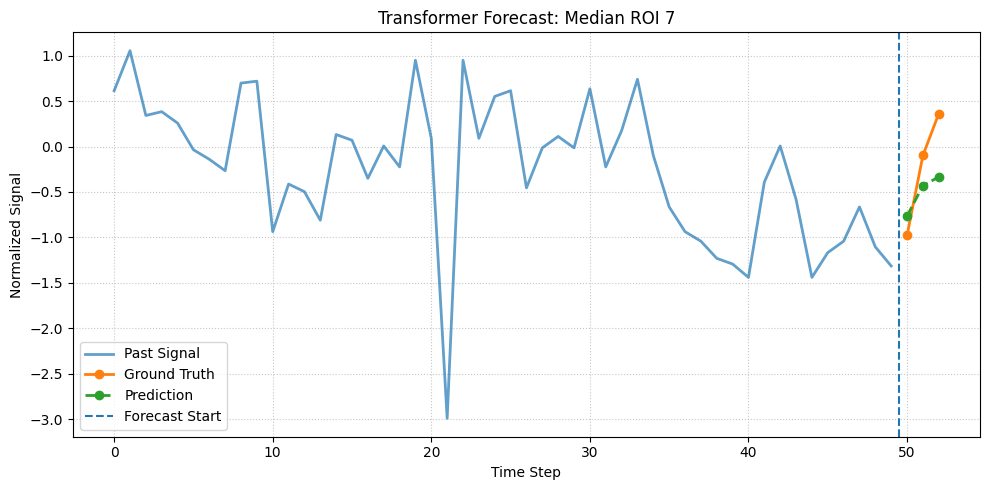

Saved figure: results_paper/transformer/figures/forecast_example_worst_roi.png


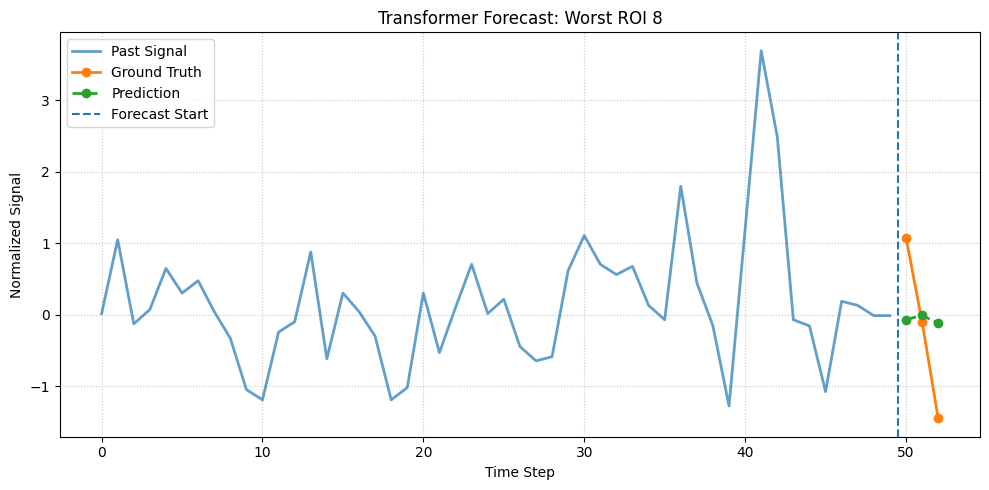

In [17]:
def select_forecast_sample(Y_true, Y_pred, roi_list):
    activity = np.mean(np.abs(Y_true[:, :, roi_list]), axis=(1, 2))
    error = np.mean((Y_true[:, :, roi_list] - Y_pred[:, :, roi_list]) ** 2, axis=(1, 2))

    activity_rank = pd.Series(activity).rank(pct=True).to_numpy()
    error_rank = pd.Series(error).rank(pct=True).to_numpy()

    score = np.abs(activity_rank - 0.75) + np.abs(error_rank - 0.50)
    return int(np.argmin(score))


def plot_forecast_example(X, Y, Yhat, roi_idx, sample_idx, title, filename):
    past_time = np.arange(X.shape[1])
    future_time = np.arange(X.shape[1], X.shape[1] + Y.shape[1])

    plt.figure(figsize=(10, 5))
    plt.plot(
        past_time,
        X[sample_idx, :, roi_idx],
        label="Past Signal",
        linewidth=2,
        alpha=0.7,
    )
    plt.plot(
        future_time,
        Y[sample_idx, :, roi_idx],
        "o-",
        label="Ground Truth",
        linewidth=2,
    )
    plt.plot(
        future_time,
        Yhat[sample_idx, :, roi_idx],
        "o--",
        label="Prediction",
        linewidth=2,
    )
    plt.axvline(
        x=X.shape[1] - 0.5,
        linestyle="--",
        label="Forecast Start",
    )
    plt.xlabel("Time Step")
    plt.ylabel("Normalized Signal")
    plt.title(title)
    plt.legend()
    plt.grid(True, linestyle=":", alpha=0.7)
    savefig(filename)


selected_rois = [best_roi, median_roi, worst_roi]
example_idx = select_forecast_sample(targets, preds, selected_rois)

print(f"Selected sample index: {example_idx}")
print(f"Best ROI: {best_roi}")
print(f"Median ROI: {median_roi}")
print(f"Worst ROI: {worst_roi}")

plot_forecast_example(
    X_test,
    targets,
    preds,
    roi_idx=best_roi,
    sample_idx=example_idx,
    title=f"Transformer Forecast: Best ROI {best_roi}",
    filename="forecast_example_best_roi.png",
)

plot_forecast_example(
    X_test,
    targets,
    preds,
    roi_idx=median_roi,
    sample_idx=example_idx,
    title=f"Transformer Forecast: Median ROI {median_roi}",
    filename="forecast_example_median_roi.png",
)

plot_forecast_example(
    X_test,
    targets,
    preds,
    roi_idx=worst_roi,
    sample_idx=example_idx,
    title=f"Transformer Forecast: Worst ROI {worst_roi}",
    filename="forecast_example_worst_roi.png",
)

Saved figure: results_paper/transformer/figures/prediction_vs_truth_scatter.png


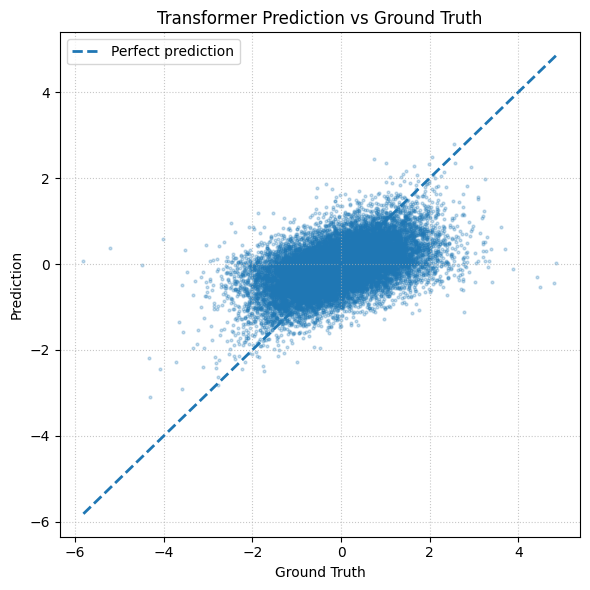

In [18]:
rng = np.random.default_rng(CONFIG.random_seed)

yt_flat = targets.ravel()
yp_flat = preds.ravel()

sample_size = min(CONFIG.scatter_sample_size, len(yt_flat))
idx = rng.choice(len(yt_flat), size=sample_size, replace=False)

plt.figure(figsize=(6, 6))
plt.scatter(yt_flat[idx], yp_flat[idx], s=4, alpha=0.25)

lims = [
    min(yt_flat[idx].min(), yp_flat[idx].min()),
    max(yt_flat[idx].max(), yp_flat[idx].max()),
]

plt.plot(lims, lims, linestyle="--", linewidth=2, label="Perfect prediction")
plt.xlabel("Ground Truth")
plt.ylabel("Prediction")
plt.title("Transformer Prediction vs Ground Truth")
plt.grid(True, linestyle=":", alpha=0.7)
plt.legend()
savefig("prediction_vs_truth_scatter.png")

{'mean_residual': -0.00436826515942812, 'std_residual': 0.8020854592323303, 'median_residual': -0.0064077493734657764, 'mean_abs_error': 0.6116294264793396}
Saved figure: results_paper/transformer/figures/residual_histogram.png


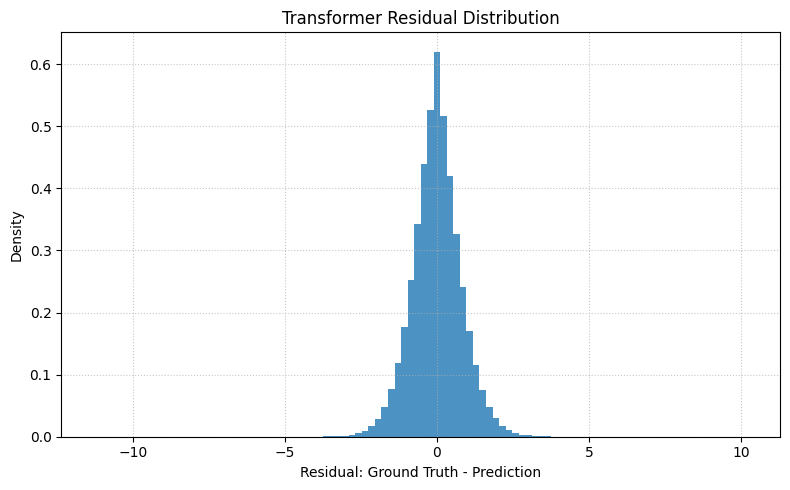

In [19]:
residuals = targets - preds
res_flat = residuals.ravel()

residual_summary = {
    "mean_residual": float(np.mean(res_flat)),
    "std_residual": float(np.std(res_flat)),
    "median_residual": float(np.median(res_flat)),
    "mean_abs_error": float(np.mean(np.abs(res_flat))),
}

pd.DataFrame([residual_summary]).to_csv(Path(CONFIG.results_dir) / "residual_summary.csv", index=False)

print(residual_summary)

plt.figure(figsize=(8, 5))
plt.hist(res_flat, bins=100, density=True, alpha=0.8)
plt.xlabel("Residual: Ground Truth - Prediction")
plt.ylabel("Density")
plt.title("Transformer Residual Distribution")
plt.grid(True, linestyle=":", alpha=0.7)
savefig("residual_histogram.png")

residual_quantiles = {}

for r in range(n_roi):
    vals = residuals[:, :, r].reshape(-1)
    residual_quantiles[int(r)] = {
        "q025": float(np.quantile(vals, 0.025)),
        "q16": float(np.quantile(vals, 0.16)),
        "q84": float(np.quantile(vals, 0.84)),
        "q975": float(np.quantile(vals, 0.975)),
    }

with open(Path(CONFIG.results_dir) / "empirical_residual_quantiles.json", "w") as f:
    json.dump(residual_quantiles, f, indent=2)

Saved figure: results_paper/transformer/figures/empirical_probabilistic_forecast_roi_11.png


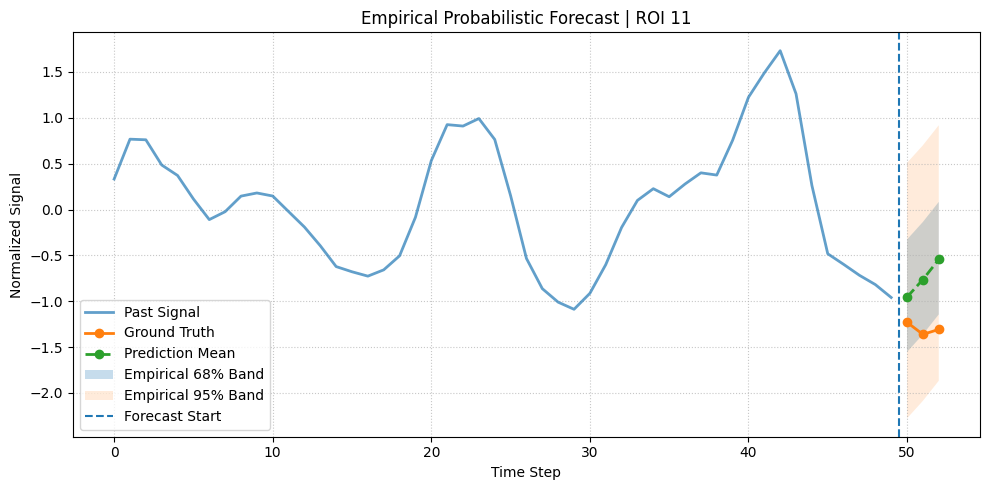

In [20]:
def plot_empirical_uncertainty_forecast(X, Y, Yhat, roi_idx, sample_idx, residual_quantiles, filename):
    past_time = np.arange(X.shape[1])
    future_time = np.arange(X.shape[1], X.shape[1] + Y.shape[1])

    mu = Yhat[sample_idx, :, roi_idx]
    y = Y[sample_idx, :, roi_idx]
    q = residual_quantiles[int(roi_idx)]

    lower_68 = mu + q["q16"]
    upper_68 = mu + q["q84"]
    lower_95 = mu + q["q025"]
    upper_95 = mu + q["q975"]

    plt.figure(figsize=(10, 5))
    plt.plot(past_time, X[sample_idx, :, roi_idx], label="Past Signal", linewidth=2, alpha=0.7)
    plt.plot(future_time, y, "o-", label="Ground Truth", linewidth=2)
    plt.plot(future_time, mu, "o--", label="Prediction Mean", linewidth=2)
    plt.fill_between(future_time, lower_68, upper_68, alpha=0.25, label="Empirical 68% Band")
    plt.fill_between(future_time, lower_95, upper_95, alpha=0.15, label="Empirical 95% Band")
    plt.axvline(x=X.shape[1] - 0.5, linestyle="--", label="Forecast Start")
    plt.xlabel("Time Step")
    plt.ylabel("Normalized Signal")
    plt.title(f"Empirical Probabilistic Forecast | ROI {roi_idx}")
    plt.legend()
    plt.grid(True, linestyle=":", alpha=0.7)
    savefig(filename)


plot_empirical_uncertainty_forecast(
    X_test,
    targets,
    preds,
    roi_idx=best_roi,
    sample_idx=example_idx,
    residual_quantiles=residual_quantiles,
    filename=f"empirical_probabilistic_forecast_roi_{best_roi}.png",
)

Mean empirical MI: 0.1764924172314037
Mean empirical entropy: 2.20071616743358
Mean normalized empirical MI: 0.0811536598893234
Saved figure: results_paper/transformer/figures/entropy_per_roi.png


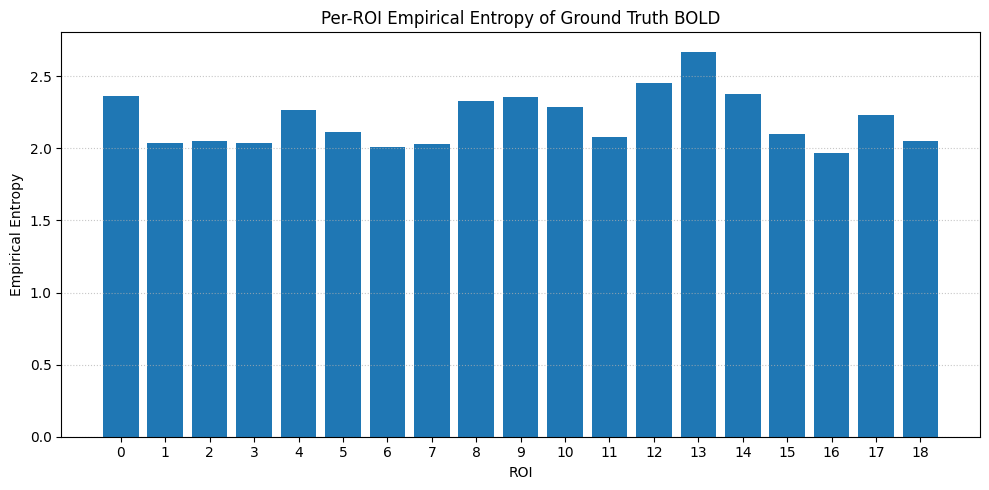

Saved figure: results_paper/transformer/figures/empirical_mi_per_roi.png


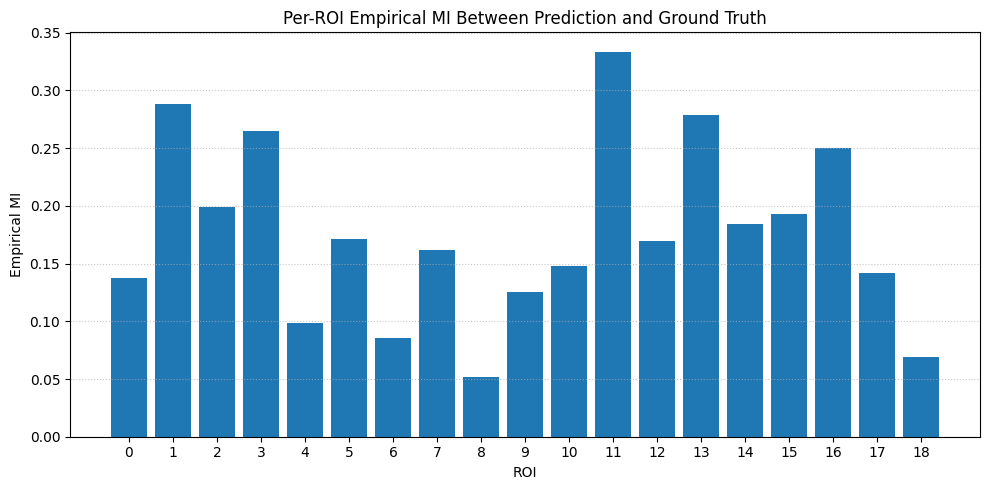

In [21]:
information_df = per_roi_df[[
    "roi",
    "empirical_entropy",
    "empirical_mi",
    "normalized_empirical_mi",
]].copy()

information_df.to_csv(Path(CONFIG.results_dir) / "information_per_roi.csv", index=False)

print("Mean empirical MI:", information_df["empirical_mi"].mean())
print("Mean empirical entropy:", information_df["empirical_entropy"].mean())
print("Mean normalized empirical MI:", information_df["normalized_empirical_mi"].mean())

plt.figure(figsize=(10, 5))
plt.bar(information_df["roi"].astype(str), information_df["empirical_entropy"])
plt.xlabel("ROI")
plt.ylabel("Empirical Entropy")
plt.title("Per-ROI Empirical Entropy of Ground Truth BOLD")
plt.grid(axis="y", linestyle=":", alpha=0.7)
savefig("entropy_per_roi.png")

plt.figure(figsize=(10, 5))
plt.bar(information_df["roi"].astype(str), information_df["empirical_mi"])
plt.xlabel("ROI")
plt.ylabel("Empirical MI")
plt.title("Per-ROI Empirical MI Between Prediction and Ground Truth")
plt.grid(axis="y", linestyle=":", alpha=0.7)
savefig("empirical_mi_per_roi.png")

Empirical MI matrix similarity: 0.795546
Saved figure: results_paper/transformer/figures/true_cross_roi_empirical_mi_heatmap.png


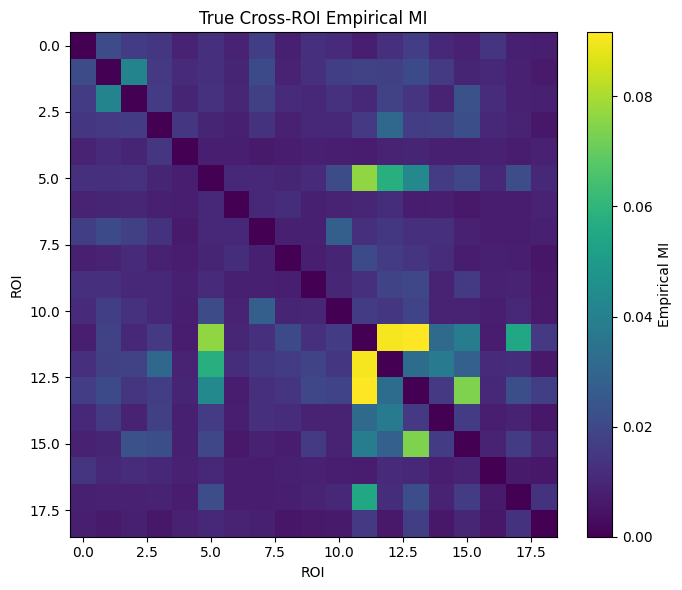

Saved figure: results_paper/transformer/figures/predicted_cross_roi_empirical_mi_heatmap.png


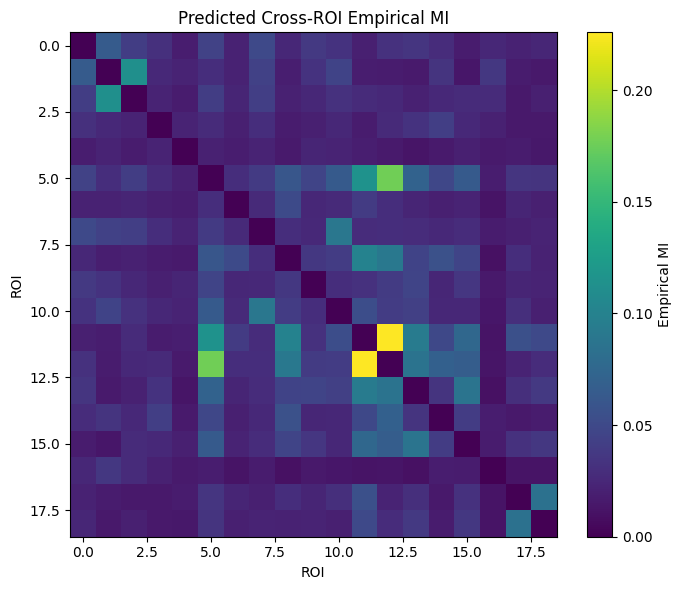

Saved figure: results_paper/transformer/figures/cross_roi_empirical_mi_difference_heatmap.png


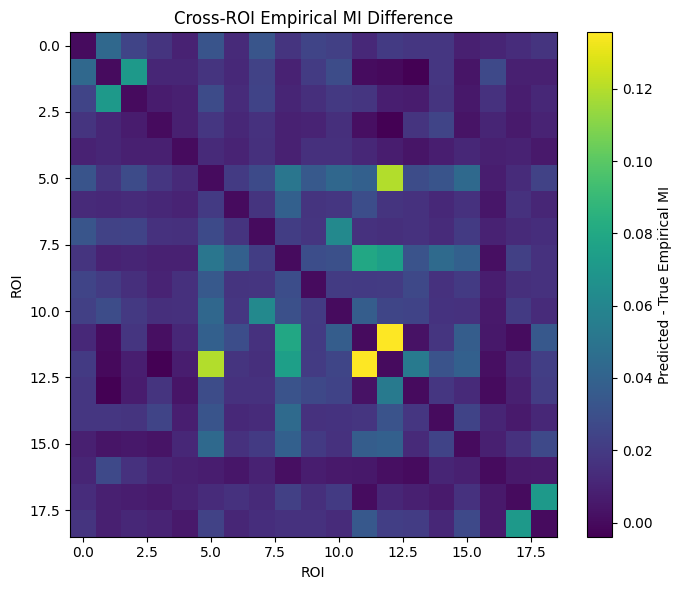

In [22]:
true_mi = empirical_cross_roi_mi_matrix(
    targets,
    bins=CONFIG.mi_bins,
    sample_size=CONFIG.mi_sample_size,
    seed=CONFIG.random_seed,
)

pred_mi = empirical_cross_roi_mi_matrix(
    preds,
    bins=CONFIG.mi_bins,
    sample_size=CONFIG.mi_sample_size,
    seed=CONFIG.random_seed,
)

np.save(Path(CONFIG.results_dir) / "true_cross_roi_empirical_mi.npy", true_mi)
np.save(Path(CONFIG.results_dir) / "pred_cross_roi_empirical_mi.npy", pred_mi)

mask = ~np.eye(n_roi, dtype=bool)
mi_matrix_similarity = float(np.corrcoef(true_mi[mask], pred_mi[mask])[0, 1])

pd.DataFrame([{
    "empirical_mi_matrix_similarity": mi_matrix_similarity
}]).to_csv(Path(CONFIG.results_dir) / "cross_roi_mi_similarity.csv", index=False)

print(f"Empirical MI matrix similarity: {mi_matrix_similarity:.6f}")

plt.figure(figsize=(7, 6))
plt.imshow(true_mi, aspect="auto")
plt.colorbar(label="Empirical MI")
plt.xlabel("ROI")
plt.ylabel("ROI")
plt.title("True Cross-ROI Empirical MI")
savefig("true_cross_roi_empirical_mi_heatmap.png")

plt.figure(figsize=(7, 6))
plt.imshow(pred_mi, aspect="auto")
plt.colorbar(label="Empirical MI")
plt.xlabel("ROI")
plt.ylabel("ROI")
plt.title("Predicted Cross-ROI Empirical MI")
savefig("predicted_cross_roi_empirical_mi_heatmap.png")

plt.figure(figsize=(7, 6))
plt.imshow(pred_mi - true_mi, aspect="auto")
plt.colorbar(label="Predicted - True Empirical MI")
plt.xlabel("ROI")
plt.ylabel("ROI")
plt.title("Cross-ROI Empirical MI Difference")
savefig("cross_roi_empirical_mi_difference_heatmap.png")

Source ablation: 100%|██████████| 19/19 [00:01<00:00, 11.41it/s]


Saved figure: results_paper/transformer/figures/source_ablation_empirical_mi_heatmap.png


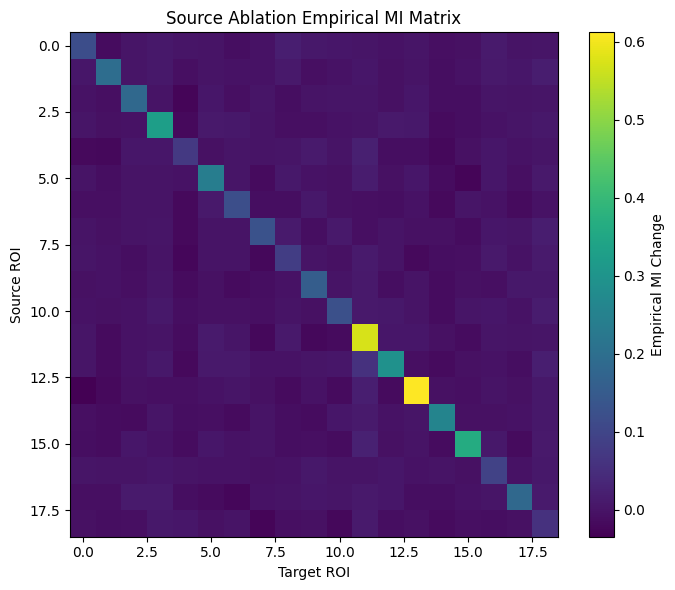

,source_roi,target_roi,empirical_mi_change
227,12,11,0.056695
281,15,11,0.024340
82,4,11,0.021493
233,12,18,0.020562
7,0,8,0.019911
245,13,11,0.018886
35,1,18,0.017081
143,7,18,0.017050
197,10,18,0.015222
100,5,11,0.015188


Saved figure: results_paper/transformer/figures/top10_source_ablation_empirical_mi_pairs.png


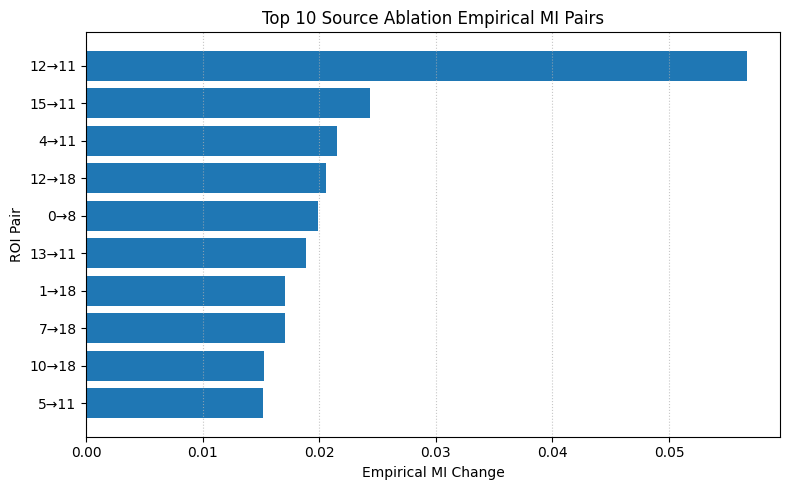

In [23]:
def predict_in_batches(model, X, device, batch_size=512):
    model.eval()

    preds_all = []

    with torch.no_grad():
        for start in tqdm(range(0, len(X), batch_size), desc="Predict batches", leave=False):
            end = min(start + batch_size, len(X))
            xb = torch.tensor(X[start:end], dtype=torch.float32).to(device)
            preds_all.append(model(xb).cpu().numpy())

    return np.concatenate(preds_all, axis=0)


def compute_source_ablation_empirical_mi(
    model,
    X,
    Y,
    full_pred,
    device,
    sample_size=1500,
    batch_size=512,
    seed=42,
    bins=32,
    horizon_idx=0,
):
    rng = np.random.default_rng(seed)

    take = min(sample_size, len(X))
    idx = rng.choice(len(X), size=take, replace=False)

    X_sub = X[idx].copy()
    Y_sub = Y[idx]
    full_sub = full_pred[idx]

    n_roi = X_sub.shape[2]
    score = np.zeros((n_roi, n_roi), dtype=np.float64)

    for source_roi in tqdm(range(n_roi), desc="Source ablation"):
        X_reduced = X_sub.copy()
        source_mean = X_reduced[:, :, source_roi].mean(axis=1, keepdims=True)
        X_reduced[:, :, source_roi] = source_mean

        reduced_pred = predict_in_batches(
            model,
            X_reduced,
            device=device,
            batch_size=batch_size,
        )

        for target_roi in range(n_roi):
            y = Y_sub[:, horizon_idx, target_roi]
            p_full = full_sub[:, horizon_idx, target_roi]
            p_reduced = reduced_pred[:, horizon_idx, target_roi]

            mi_full = empirical_mi_1d(y, p_full, bins=bins)
            mi_reduced = empirical_mi_1d(y, p_reduced, bins=bins)

            score[source_roi, target_roi] = mi_full - mi_reduced

    return score


ablation_mi = compute_source_ablation_empirical_mi(
    model=model,
    X=X_test,
    Y=targets,
    full_pred=preds,
    device=device,
    sample_size=CONFIG.ablation_sample_size,
    batch_size=CONFIG.batch_size,
    seed=CONFIG.random_seed,
    bins=CONFIG.mi_bins,
    horizon_idx=0,
)

np.save(Path(CONFIG.results_dir) / "source_ablation_empirical_mi.npy", ablation_mi)

plt.figure(figsize=(7, 6))
plt.imshow(ablation_mi, aspect="auto")
plt.colorbar(label="Empirical MI Change")
plt.xlabel("Target ROI")
plt.ylabel("Source ROI")
plt.title("Source Ablation Empirical MI Matrix")
savefig("source_ablation_empirical_mi_heatmap.png")

pairs = []
for i in range(n_roi):
    for j in range(n_roi):
        if i == j:
            continue
        pairs.append({
            "source_roi": i,
            "target_roi": j,
            "empirical_mi_change": float(ablation_mi[i, j]),
        })

pairs_df = pd.DataFrame(pairs).sort_values("empirical_mi_change", ascending=False)
pairs_df.to_csv(Path(CONFIG.results_dir) / "source_ablation_empirical_mi_pairs.csv", index=False)

display(pairs_df.head(10))

top = pairs_df.head(10).iloc[::-1]

plt.figure(figsize=(8, 5))
plt.barh(
    [f"{int(r.source_roi)}→{int(r.target_roi)}" for _, r in top.iterrows()],
    top["empirical_mi_change"],
)
plt.xlabel("Empirical MI Change")
plt.ylabel("ROI Pair")
plt.title("Top 10 Source Ablation Empirical MI Pairs")
plt.grid(axis="x", linestyle=":", alpha=0.7)
savefig("top10_source_ablation_empirical_mi_pairs.png")

In [24]:
summary_lines = []

summary_lines.append("Transformer fMRI forecasting report outputs")
summary_lines.append("=" * 60)
summary_lines.append("")
summary_lines.append("Dataset / windowing")
summary_lines.append(f"- Root dir: {CONFIG.root_dir}")
summary_lines.append(f"- Raw runs loaded: {metadata['num_raw_runs']}")
summary_lines.append(f"- Train runs: {metadata['train_runs']}")
summary_lines.append(f"- Test runs: {metadata['test_runs']}")
summary_lines.append(f"- Train subjects: {metadata['train_subjects']}")
summary_lines.append(f"- Test subjects: {metadata['test_subjects']}")
summary_lines.append(f"- M: {CONFIG.M}")
summary_lines.append(f"- H: {CONFIG.H}")
summary_lines.append(f"- Stride: {CONFIG.stride}")
summary_lines.append(f"- Number of ROIs: {n_roi}")
summary_lines.append("")
summary_lines.append("Model")
summary_lines.append(f"- Architecture: Transformer encoder")
summary_lines.append(f"- d_model: {CONFIG.d_model}")
summary_lines.append(f"- nhead: {CONFIG.nhead}")
summary_lines.append(f"- num_layers: {CONFIG.num_layers}")
summary_lines.append(f"- dropout: {CONFIG.dropout}")
summary_lines.append(f"- trainable parameters: {trainable_params:,}")
summary_lines.append("")
summary_lines.append("Forecasting metrics")
summary_lines.append(f"- RMSE: {model_rmse:.6f}")
summary_lines.append(f"- Naive RMSE: {naive_rmse:.6f}")
summary_lines.append(f"- RMSSE: {model_rmsse:.6f}")
summary_lines.append(f"- PVE: {pve:.6f}")
summary_lines.append(f"- Overall correlation: {overall_corr:.6f}")
summary_lines.append(f"- Beat naive: {model_rmse < naive_rmse}")
summary_lines.append(f"- Train time minutes: {train_time_minutes:.2f}")
summary_lines.append("")
summary_lines.append("Horizon RMSE")
for h, score in enumerate(horizon_scores, start=1):
    summary_lines.append(f"- Step {h}: {score:.6f}")
summary_lines.append("")
summary_lines.append("ROI examples")
summary_lines.append(f"- Best ROI by PVE: {best_roi}")
summary_lines.append(f"- Median ROI by PVE: {median_roi}")
summary_lines.append(f"- Worst ROI by PVE: {worst_roi}")
summary_lines.append("")
summary_lines.append("Empirical information metrics")
summary_lines.append(f"- Mean empirical MI: {information_df['empirical_mi'].mean():.6f}")
summary_lines.append(f"- Mean empirical entropy: {information_df['empirical_entropy'].mean():.6f}")
summary_lines.append(f"- Mean normalized empirical MI: {information_df['normalized_empirical_mi'].mean():.6f}")
summary_lines.append(f"- Cross-ROI empirical MI matrix similarity: {mi_matrix_similarity:.6f}")

summary_text = "\n".join(summary_lines)

report_path = Path(CONFIG.results_dir) / "report_summary.txt"
report_path.write_text(summary_text)

print(summary_text)
print(f"\nSaved report summary: {report_path}")

Transformer fMRI forecasting report outputs

Dataset / windowing
- Root dir: data/pooled_stratified_share
- Raw runs loaded: 2144
- Train runs: 1440
- Test runs: 704
- Train subjects: ['subjoVC0sHUB_P', 'subjqFdsBbuiHF', 'subjtySNgRhV65', 'subjxpYwO4azeZ']
- Test subjects: ['subjOenz4SHyaO', 'subjQX6R7rImeb']
- M: 50
- H: 3
- Stride: 1
- Number of ROIs: 19

Model
- Architecture: Transformer encoder
- d_model: 64
- nhead: 4
- num_layers: 2
- dropout: 0.1
- trainable parameters: 570,489

Forecasting metrics
- RMSE: 0.802097
- Naive RMSE: 0.991941
- RMSSE: 1.011876
- PVE: 0.264600
- Overall correlation: 0.515769
- Beat naive: True
- Train time minutes: 9.30

Horizon RMSE
- Step 1: 0.703650
- Step 2: 0.829655
- Step 3: 0.864077

ROI examples
- Best ROI by PVE: 11
- Median ROI by PVE: 7
- Worst ROI by PVE: 8

Empirical information metrics
- Mean empirical MI: 0.176492
- Mean empirical entropy: 2.200716
- Mean normalized empirical MI: 0.081154
- Cross-ROI empirical MI matrix similarity: 0.79

In [25]:
print("Generated result files:")
for p in sorted(Path(CONFIG.results_dir).glob("*")):
    if p.is_file():
        print(" -", p)

print("\nGenerated figures:")
for p in sorted(Path(CONFIG.figure_dir).glob("*")):
    print(" -", p)

Generated result files:
 - results_paper/transformer/Y_pred_transformer.npy
 - results_paper/transformer/Y_true_transformer.npy
 - results_paper/transformer/cross_roi_mi_similarity.csv
 - results_paper/transformer/dataset_metadata.json
 - results_paper/transformer/empirical_residual_quantiles.json
 - results_paper/transformer/horizon_rmse.csv
 - results_paper/transformer/information_per_roi.csv
 - results_paper/transformer/model_config.json
 - results_paper/transformer/per_roi_metrics.csv
 - results_paper/transformer/pred_cross_roi_empirical_mi.npy
 - results_paper/transformer/report_summary.txt
 - results_paper/transformer/residual_summary.csv
 - results_paper/transformer/source_ablation_empirical_mi.npy
 - results_paper/transformer/source_ablation_empirical_mi_pairs.csv
 - results_paper/transformer/summary_for_report.csv
 - results_paper/transformer/summary_for_report.json
 - results_paper/transformer/training_history.csv
 - results_paper/transformer/true_cross_roi_empirical_mi.npy

